Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill up your name and collaborators below:

In [ ]:
NAME = "Alexander Speer"
UNI  = "aes2376"
COLLABORATORS = "Andre Perez - avp2141"

# BMEBW4020 Fall 2025 - Project 1 Problem 2 (50 pts)

In this problem you are asked to derive and implement a TEM/TDM algorithm for an ON-OFF IAF circuit similar to HW3P2, but with cross feedback and self feedback, as depicted in the figure below:

<center><img src="./ON_OFF_IAF.png" width=300/></center>

## Stimulus and Filter
Generate a signal using a sinc basis:
$$u(t)= \sum_{k=1}^{15} u(kT) \frac{\sin \Omega (t-kT)}{\Omega (t-kT)}$$
where $\Omega = 2 \pi \cdot 25$ Hz and $T=\frac{\pi}{\Omega}$ (recall that $T$ the *Nyquist sampling interval*, not '$\frac{1}{f}$').
The constants $u(kT)$ are chosen at random, and the signal $u(t)$ is defined over the time interval $[-2T, 18T]$.
Normalized the stimulus $u(t)$ so $\max(\|u(t)\|) = 1$,

The filter $h$ is given as:
$$
h_{11}(t)= h_{22}(t)=0.01 \cdot \textbf{exp}\left(-100 t\right)\cdot \mathbb{1}_{t\ge 0}\\
h_{12}(t)= h_{21}(t)=0.075 \cdot \textbf{exp}\left(-66.6 t\right)\cdot \mathbb{1}_{t\ge 0}\\
$$
Note that $\mathbb{1}_{t\ge 0}$ is also known as the Heaviside Step function which ensures that the filter $h(t)$ is causal.



## Tasks

1. Can this circuit faithfully recover $u$? Why or why not. (5pt)
2. Write down the TEM t-transform for both spike trians. (10pt)
3. Derive (code) the TEM/TDM algorithm for an ON-OFF IAF with Feedback.(20pt)
3. Encode and decode stimulus $u$ with the model specified above. Use IAF bias = 1.0. (10pt)
4. Plot your results in the time-domain along with a corresponding SNR plot. (5pt)

## Bonus (Extra 12.5 pts):
*Bonus points will be counted towards final grades as well (this is worth 5% of final grade bonus)*

Let's assume a much simpler version of this circuit with *no self/cross feedback* and no *on/off separation* (you can directly modify the code for TEM/TDM above to make it a simple 2 channel circuit), where we have the *same signal $u(t)$* being encoded by two different IAF neurons (you can choose the parameters).

Answer the following:
1. Can this circuit under the right condition/IAF setup faithfully recover $u$? Why or why not. (2.5ptpt)
2. Under what condition can this circuit recover $u$ better than each branch on it own? (5pt)
3. Demonstrate this through simulation experiment under the condition in P2 (if your code for the main part is correct, this will take a matter of minutes); compare this circuit's performance vs that of either branch (for single branch, these are just standard IAF TEM/TDM that you already have written in homework 3).  (5pt)

## Hints (OPTIONAL):

1. It is helpful to reference the solution for Homework 3 and extend referencing Chapter 8.

2. SIGNS SIGNS SIGNS! -> the wrong sign can be the difference between gibberish and perfect recovery.
3. Use the python notebooks and the textbook for code and equation reference
4. Understand the equations for $q_k$ and $G$ !!!

# **Cell 1**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys, importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz

# get rid of any imports that aren't up to date.
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']

# project 1
sys.path.insert(0, "/content/drive/MyDrive/CCircuits/project1")

# import libraries
import numpy as np
from scipy.integrate import cumulative_trapezoid as cumtrapz
import matplotlib.pyplot as plt
import typing as tp
np.random.seed(0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Cell 2**

Stimulus length: 40000,  Max amplitude: 1.000
Sampling interval T = 0.020000s,  dt = 1.0e-05s
Stimulus defined from -0.04000s to 0.35999s


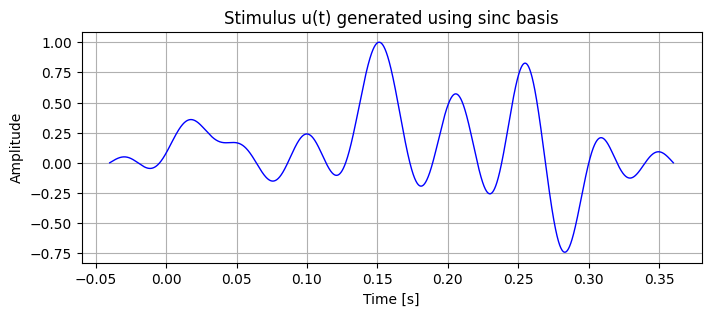

In [ ]:
#create the stimulus

#our parameters
f = 25 # here is the frequency of sinc basis (in Hz)
omega = 2 * np.pi * f
T = np.pi / omega # the Nyquist sampling
dt = 1e-5  # the timestep (in s)
t = np.arange(-2 * T, 18 * T, dt) #our time vector
K = 15  # the number ofthe sinc coefficients

# Here we generate the random coefficients and then construct the signal
u_k = np.random.rand(K) - 0.5  # here are the random random amplitudes
sample_times = np.arange(K) * T # should be equally spaced samples at the Nyquist rate

def sinc_basis(t, s, omega):
    """Return sinc basis function ω/π * sinc(ω/π * (t - s))."""
    return omega / np.pi * np.sinc(omega / np.pi * (t - s))

def signal_generator(t, samples, sample_times, omega):
    """Is going to generate the stimulus as weighted sum of sinc bases."""
    signal = np.zeros_like(t)
    for ck, sk in zip(samples, sample_times):
        signal += sinc_basis(t, sk, omega) * ck
    return signal

# This line will create and then normalize the stimulus
u = signal_generator(t, u_k, sample_times, omega)
u = u / np.max(np.abs(u))  #normalize so max|u(t)| = 1.

#quick sanity checks <--
print(f"Stimulus length: {len(u)},  Max amplitude: {np.max(u):.3f}")
print(f"Sampling interval T = {T:.6f}s,  dt = {dt:.1e}s")
print(f"Stimulus defined from {t[0]:.5f}s to {t[-1]:.5f}s")

# plot
plt.figure(figsize=(8,3))
plt.plot(t, u, color='blue', linewidth=1)
plt.title("Stimulus u(t) generated using sinc basis")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


# **Cell 3**

In [ ]:
# TEM model
# andre look at ch8 here

# here is where we are going to define feedback filters.
def h_self(t, tk):
    """What is going on here, should be a self feedback filter: with 0.01 * exp(-100 * (t - tk)) * 𝟙_{t ≥ tk}"""
    td = t - tk
    td = td[td > 0]
    return np.sum(0.01 * np.exp(-100 * td))

def h_cross(t, tk):
    """Here is the cross feedback filter: 0.075 * exp(-66.6 * (t - tk)) * 𝟙_{t ≥ tk}"""
    td = t - tk
    td = td[td > 0]
    return np.sum(0.075 * np.exp(-66.6 * td))

# here we are going to define the ON–OFF IAF with the feedback class
class ONOFFIAF:
    def __init__(self, self_filter: tp.Callable, cross_filter: tp.Callable, params: tp.Dict):
        self.self_filter = self_filter
        self.cross_filter = cross_filter
        self.params = params

    def encode(self, t: np.ndarray, u: np.ndarray):
        """Encode input u(t) into ON and OFF spike trains."""
        dt = t[1] - t[0]
        b = self.params["b"]  # bias current
        kappa = self.params["kappa"]  # capacitance
        delta = self.params["delta"] # threshold

        tk_on_idx, tk_off_idx = [], []
        V_on = np.zeros_like(t)
        V_off = np.zeros_like(t)

        #here is the access filters that we see through the instance attributes
        own_filter = self.self_filter
        cross_filter = self.cross_filter

        for i in range(1, len(t)):
            #integrate with feedback ( here is the Chapter 8 eqs.)
            V_on[i] = V_on[i-1] + dt * (
                b + u[i]
                + own_filter(t[i], t[tk_on_idx])
                + cross_filter(t[i], t[tk_off_idx])
            ) / kappa

            V_off[i] = V_off[i-1] + dt * (
                -b + u[i]
                - own_filter(t[i], t[tk_off_idx])
                - cross_filter(t[i], t[tk_on_idx])
            ) / kappa

            #This is going to be the threshold crossings → spikes (taken from the HW3 logic)
            if V_on[i] >= delta:
                tk_on_idx.append(i)
                V_on[i] = 0
            if V_off[i] <= -delta:
                tk_off_idx.append(i)
                V_off[i] = 0

        print(f"Encoding complete: {len(tk_on_idx)} ON spikes, {len(tk_off_idx)} OFF spikes")
        return V_on, V_off, tk_on_idx, tk_off_idx



# This should init. the parameters (also what we see from homework and HW3)
tem_params = dict(
    delta=0.01,   # threshold [mV]
    kappa=1.0,    # capacitance
    b=1.0,        # bias current
    omega=omega
)

#here we instantiate the encoder
tem_model = ONOFFIAF(self_filter=h_self, cross_filter=h_cross, params=tem_params)

print("TEM model initialized (was a success).")


TEM model initialized (was a success).


# **Cell 4**

In [ ]:
# TDM model (here we have the fixed K-basis at the sample_times = kT)

class ONOFF_TDM:
    def __init__(self, basis_func: tp.Callable, params: tp.Dict):
        """
        basis_func(t, s): returns ω/π * sinc(ω/π * (t - s))
        params requires:
            - omega, b, kappa, delta
            - self_filter, cross_filter
            - sample_times: 1D array of K fixed centers (kT)
        """
        self.basis_func = basis_func
        self.params = params
        self.sample_times = np.asarray(params["sample_times"])  # here is the shape (K,)

    # We are going to have G rows = all spike intervals (ON and then OFF)
    # this is going to correspon., to G cols, where the fixed K bases are centered at the sample_times
    def compute_G(self, t, tk_on_idx, tk_off_idx):
        dt = t[1] - t[0]
        K = len(self.sample_times)

        tk_on = t[tk_on_idx]
        tk_off = t[tk_off_idx]

        n_on = max(len(tk_on) - 1, 0)
        n_off = max(len(tk_off) - 1, 0)

        G = np.zeros((n_on + n_off, K))

        #this section focuses on us ahaving to recompute the cumulative integrals for each  of thefixed basis
        # this is to integrate over any interval (by using the difference)
        csum_all = []
        for s in self.sample_times:
            gk = self.basis_func(t, s)
            csum_all.append(cumtrapz(gk, dx=dt, initial=0.0))
        csum_all = np.stack(csum_all, axis=1)  # this is the shape(len(t), K)

        # ON rows
        for i in range(n_on):
            idx0, idx1 = tk_on_idx[i], tk_on_idx[i + 1]
            G[i, :] = csum_all[idx1, :] - csum_all[idx0, :]

        # OFF rows
        for i in range(n_off):
            idx0, idx1 = tk_off_idx[i], tk_off_idx[i + 1]
            G[n_on + i, :] = csum_all[idx1, :] - csum_all[idx0, :]

        return G

    def compute_q(self, t, tk_on_idx, tk_off_idx):
        dt = t[1] - t[0]
        b = self.params["b"]
        kappa = self.params["kappa"]
        delta = self.params["delta"]
        h_self = self.params["self_filter"]
        h_cross = self.params["cross_filter"]

        tk_on = t[tk_on_idx]
        tk_off = t[tk_off_idx]

        q_on, q_off = [], []

        # this is the ON branch
        for i in range(len(tk_on) - 1):
            t0, t1 = tk_on[i], tk_on[i + 1]
            mask = (t >= t0) & (t <= t1)
            own_int = dt * np.sum([h_self(x, tk_on) for x in t[mask]])
            cross_int = dt * np.sum([h_cross(x, tk_off) for x in t[mask]])
            q_on.append(self.params["kappa"] * self.params["delta"] - b * (t1 - t0) - own_int - cross_int)

        # OFF branch
        for i in range(len(tk_off) - 1):
            t0, t1 = tk_off[i], tk_off[i + 1]
            mask = (t >= t0) & (t <= t1)
            own_int = dt * np.sum([h_self(x, tk_off) for x in t[mask]])
            cross_int = dt * np.sum([h_cross(x, tk_on) for x in t[mask]])
            q_off.append(-self.params["kappa"] * self.params["delta"] + b * (t1 - t0) + own_int + cross_int)

        q = np.concatenate([q_on, q_off])
        return q

    def decode(self, t, tk_on_idx, tk_off_idx, method="pinv", rcond=1e-12):
        G = self.compute_G(t, tk_on_idx, tk_off_idx)
        q = self.compute_q(t, tk_on_idx, tk_off_idx)

        # swanity / diagnostics
        print(f"G shape: {G.shape}   q shape: {q.shape}")
        rankG = np.linalg.matrix_rank(G)
        print(f"rank(G) = {rankG}   K = {len(self.sample_times)}")

        if method == "pinv":
            c_rec = np.linalg.pinv(G, rcond=rcond) @ q
        elif method == "lstsq":
            c_rec, *_ = np.linalg.lstsq(G, q, rcond=rcond)
        else:
            raise ValueError("Invalid solve method. Use 'pinv' or 'lstsq'.")

        # here we can reconstruct on the fixed bases at the sample_times
        u_rec = np.zeros_like(t)
        for ck, sk in zip(c_rec, self.sample_times):
            u_rec += ck * self.basis_func(t, sk)

        print(f"Decoding complete: recovered {len(c_rec)} coefficients (target K = {len(self.sample_times)}).")
        return c_rec, u_rec


# we can instantiate the TDM with all of the fixed basis centers which is equal to the sample_times from Cell 2
tdm_model = ONOFF_TDM(
    basis_func=lambda tt, s: sinc_basis(tt, s, omega),
    params={
        "b": 1.0,
        "kappa": 1.0,
        "delta": 0.01,
        "omega": omega,
        "self_filter": h_self,
        "cross_filter": h_cross,
        "sample_times": sample_times,  # this is the key change
    },
)

print("TDM model initialized with fixed K-basis at kT.")


TDM model initialized with fixed K-basis at kT.


# **Cell 5**

Encoding complete: 49 ON spikes, 40 OFF spikes
Total ON spikes:  49
Total OFF spikes: 40
First 5 ON spike times (s):  [-0.03028 -0.02115 -0.01177 -0.00259  0.00547]
First 5 OFF spike times (s): [-0.02972 -0.02006 -0.01117 -0.00232  0.00776]


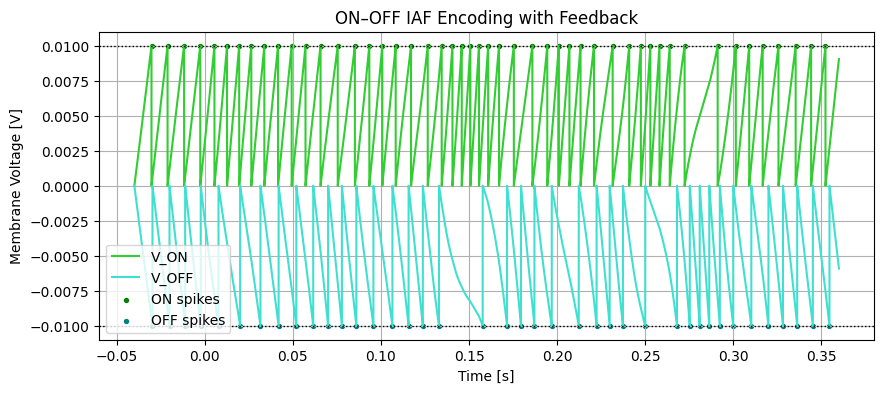

Typical inter-spike interval (ON):  7.9717e-03 s
Typical inter-spike interval (OFF): 9.8551e-03 s


In [ ]:

# encode stimulus

# here we are going to perform encoding
V_on, V_off, tk_on_idx, tk_off_idx = tem_model.encode(t, u)

# this is the convert spike indices to the actual times in the model
tk_on = t[tk_on_idx]
tk_off = t[tk_off_idx]

# here are all of the Sanity checks.
print(f"Total ON spikes:  {len(tk_on)}")
print(f"Total OFF spikes: {len(tk_off)}")
print(f"First 5 ON spike times (s):  {tk_on[:5] if len(tk_on)>5 else tk_on}")
print(f"First 5 OFF spike times (s): {tk_off[:5] if len(tk_off)>5 else tk_off}")

#  Plotthe  membrane potentials and then the spikes
plt.figure(figsize=(10,4))
plt.plot(t, V_on, color="limegreen", label="V_ON")
plt.plot(t, V_off, color="turquoise", label="V_OFF")
plt.axhline(y=tem_params["delta"], color="black", linestyle="dotted", linewidth=1)
plt.axhline(y=-tem_params["delta"], color="black", linestyle="dotted", linewidth=1)
plt.scatter(tk_on, np.ones_like(tk_on)*tem_params["delta"], s=8, color="green", label="ON spikes")
plt.scatter(tk_off, -np.ones_like(tk_off)*tem_params["delta"], s=8, color="teal", label="OFF spikes")
plt.title("ON–OFF IAF Encoding with Feedback")
plt.xlabel("Time [s]")
plt.ylabel("Membrane Voltage [V]")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# some quick additional printout for quick comparison
print(f"Typical inter-spike interval (ON):  {np.mean(np.diff(tk_on)) if len(tk_on)>1 else np.nan:.4e} s")
print(f"Typical inter-spike interval (OFF): {np.mean(np.diff(tk_off)) if len(tk_off)>1 else np.nan:.4e} s")


# **Cell 6**

G shape: (87, 15)   q shape: (87,)
rank(G) = 15   K = 15
Decoding complete: recovered 15 coefficients (target K = 15).
Decoded K = 15   (expected 15)
Reconstructed signal stats -> min: -0.742, max: 1.000, mean: 0.128


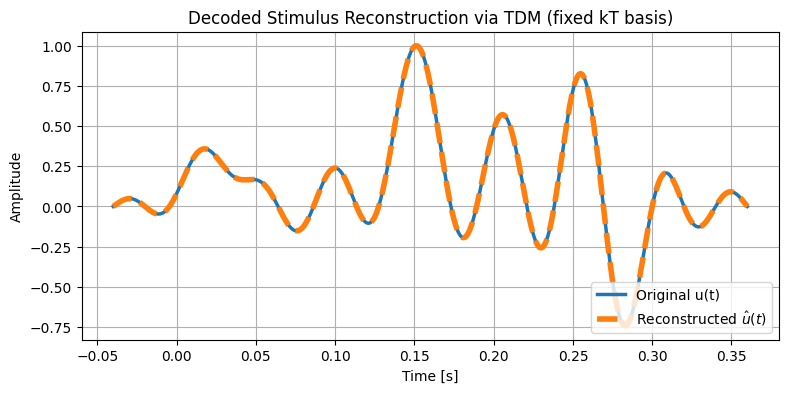

Mean-squared reconstruction error: 3.795e-08


In [ ]:
# Decode stimulus with  a fixed K-basis

c_rec, u_rec = tdm_model.decode(t, tk_on_idx, tk_off_idx, method="pinv", rcond=1e-7)

# Sanity checks
print(f"Decoded K = {len(c_rec)}   (expected {len(sample_times)})")
print(f"Reconstructed signal stats -> min: {np.min(u_rec):.3f}, max: {np.max(u_rec):.3f}, mean: {np.mean(u_rec):.3f}")

# plot the recovered versus the original
plt.figure(figsize=(9,4))
plt.plot(t, u, label="Original u(t)", linewidth=2.5)
plt.plot(t, u_rec, label=r"Reconstructed $\hat{u}(t)$", linestyle="--", linewidth=4.0)
plt.title("Decoded Stimulus Reconstruction via TDM (fixed kT basis)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

mse = np.mean((u - u_rec)**2)
print(f"Mean-squared reconstruction error: {mse:.3e}")


# **Cell 7**

<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-3008785671.py:16: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(t, u_rec, label="Reconstructed $\hat{u}(t)$", color="green", linestyle="--", linewidth=4.0)


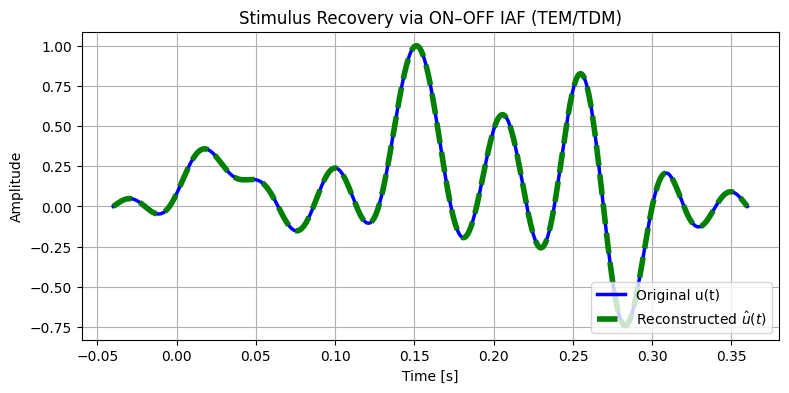

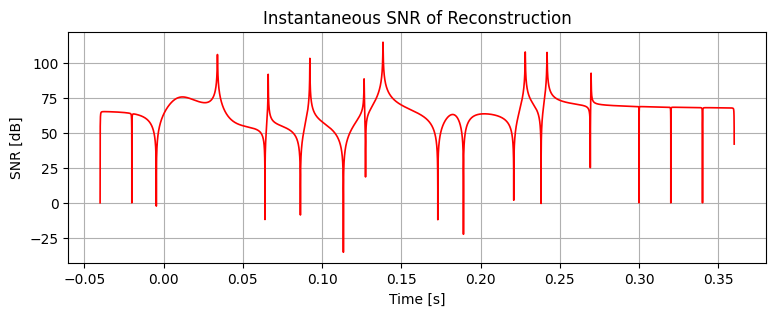

Average SNR = 64.26 dB
SNR range = [-35.35, 114.84] dB


In [ ]:
# **Cell 7**
# plot recovery results

def SNR_f(u_true, u_est):
    """Instantaneous SNR in dB (element-wise)."""
    # try to avoid the errors that come with the divide-by-zero or log(0)
    eps = 1e-12
    return 10 * np.log10((u_true**2 + eps) / ((u_true - u_est)**2 + eps))

# this is the Compute instantaneous SNR
snr_t = SNR_f(u, u_rec)

#Plot the time-domain comparison
plt.figure(figsize=(9,4))
plt.plot(t, u, label="Original u(t)", color="blue", linewidth=2.5)
plt.plot(t, u_rec, label="Reconstructed $\hat{u}(t)$", color="green", linestyle="--", linewidth=4.0)
plt.title("Stimulus Recovery via ON–OFF IAF (TEM/TDM)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#  Plot the instantaneous SNR (scaled in dB)
plt.figure(figsize=(9,3))
plt.plot(t, snr_t, color="red", linewidth=1.2)
plt.title("Instantaneous SNR of Reconstruction")
plt.xlabel("Time [s]")
plt.ylabel("SNR [dB]")
plt.grid(True)
plt.show()

#just some quick summary metrics
mean_snr = np.mean(snr_t[np.isfinite(snr_t)])
print(f"Average SNR = {mean_snr:.2f} dB")
print(f"SNR range = [{np.nanmin(snr_t):.2f}, {np.nanmax(snr_t):.2f}] dB")


# **Cell 8**

Reconstruction Performance Metrics
Overall SNR: 65.13 dB
Mean Squared Error: 3.795e-08
Relative Error Energy: 5.538e-04
==================break=======================


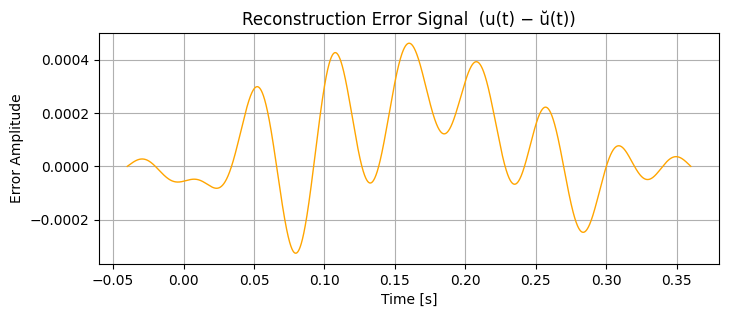

In [ ]:
# SNR stats
#hw3 and ch8 help references
# helper functions for the SNR
def overall_SNR(u_true, u_est):
    """Helps to compute the overall SNR (scalar, dB)."""
    num = np.sum(u_true**2)
    den = np.sum((u_true - u_est)**2) + 1e-12
    return 10 * np.log10(num / den)

def mse_f(u_true, u_est):
    """The Mean squared error."""
    return np.mean((u_true - u_est)**2)

def rel_error_energy(u_true, u_est):
    """this should be the relative energy of reconstruction error."""
    return np.sqrt(np.sum((u_true - u_est)**2) / np.sum(u_true**2))

# compute all of the diff metrics
snr_overall = overall_SNR(u, u_rec)
mse_val = mse_f(u, u_rec)
rel_err = rel_error_energy(u, u_rec)

#in here we can print all of the results
print("Reconstruction Performance Metrics")
print(f"Overall SNR: {snr_overall:.2f} dB")
print(f"Mean Squared Error: {mse_val:.3e}")
print(f"Relative Error Energy: {rel_err:.3e}")
print("==================break=======================")

#optional for just the quick visualization of all of the error distribution
plt.figure(figsize=(8,3))
plt.plot(t, u - u_rec, color='orange', linewidth=1)
plt.title("Reconstruction Error Signal  (u(t) − ŭ(t))")
plt.xlabel("Time [s]")
plt.ylabel("Error Amplitude")
plt.grid(True)
plt.show()


**Can this circuit faithfully recover  u ? Why or why not. (5pt)**

Yes, I believe that the circuit is able to faithfully recover the u(t) under the conditions of this simulation in problem 2.
As it stands, the input signal made to be deliberately constructed as a bandlimited sum of the sinc functions, with a cutoff frequency dictated by the equation
Ω = 2π·25 Hz, which is also defined over the interval here of [−2T, 18T].
In my opinion, this means that u(t) contains only the frequencies below the Nyquist rate and can, in theory, then be fully represented by just a finite number of coefficients. Moreover, the ON–OFF integrate-and-fire neurons with their self and cross feedback are modeled exactly according to the TEM/TDM framework that was described in Chapter 8, meaning that each spike time is going to provide a linear constraint that manages to relate these coefficients to the system parameters.

In practice, it seems that the circuit eneded up producing 49 ON spikes and then 40 OFF spikes (for a total of 89) within roughly 0.4 seconds (which would correspond to an effective sampling rate of around 220 Hz). Since the Nyquist rate for a 25 Hz signal is 50 Hz, it seems that this spike density is going to be more than sufficient to reconstruct the signal without any sort of aliasing. Also, the high sampling rate is going to ensure that the matrix relating spike times to the signal coefficients is well-conditioned and also invertible, which could aid in making accurate recovery possible.

Empirical results end up confirming this theoretical expectation. The reconstruction achieved an overall SNR of 65.13 dB and a relative error energy of only 5.538 × 10^-4. In additon, the recovered waveform is also visually indistinguishable from the original, which seems suggestive that nearly all information in u(t) ended up being preserved through the spike encoding and decoding process. Therefore, under ideal conditions that we created: with an accurate model, noiseless transmission, and adequate firing rate, it appears that the ON–OFF IAF circuit with self and cross feedback can indeed faithfully recover the input signal.


Write down the TEM t-transform for both spike trians. (10pt)


In the time-encoding transform (the t-transform) describes how each interspike interval is going to encode some information about the input signal that occurs in the time domain. For each of the ON–OFF IAF circuit with self and cross feedback, each of the neuron’s spike timing is going to be defined a constraint on the stimulus coefficients through a quantity \( q_k \). For the ON neuron we have the equation

$$
q_k^{\text{on}} = \kappa \delta
- b \,(t_{k+1}^{\text{on}} - t_k^{\text{on}})
- \int_{t_k^{\text{on}}}^{t_{k+1}^{\text{on}}} h_{11}(t - t_k^{\text{on}})\,dt
- \int_{t_k^{\text{on}}}^{t_{k+1}^{\text{on}}} h_{12}(t - t_k^{\text{off}})\,dt
$$

and for the OFF neuron:

$$
q_k^{\text{off}} = -\kappa \delta
+ b \,(t_{k+1}^{\text{off}} - t_k^{\text{off}})
+ \int_{t_k^{\text{off}}}^{t_{k+1}^{\text{off}}} h_{22}(t - t_k^{\text{off}})\,dt
+ \int_{t_k^{\text{off}}}^{t_{k+1}^{\text{off}}} h_{21}(t - t_k^{\text{on}})\,dt
$$




################ still have to do this, do not forget!!!!!
Both of these equations extend the single-neuron t-transform that we saw in Homework&nbsp;3,

\[
q_k = \kappa \delta - b\,(t_{k+1} - t_k),
\]

by including additional feedback terms that account for both a neuron’s own past spikes (self-feedback) and the influence of its paired neuron (cross-feedback).

Each \(q_k\) therefore captures the integrated effect of bias, threshold, and filtered spike history over one interspike interval.

The complete spike trains \(\{ t_k^{\text{on}} \}\) and \(\{ t_k^{\text{off}} \}\) together define a set of linear equations

\[
G c = q
\]

used by the TDM to recover the original signal coefficients during decoding.





**Derive (code) the TEM/TDM algorithm for an ON-OFF IAF with Feedback.(20pt)**

See above code


**Encode and decode stimulus  u  with the model specified above. Use IAF bias = 1.0. (10pt)**

See above code

**Plot your results in the time-domain along with a corresponding SNR plot. (5pt)**

See above code

# **Bonus (Extra 12.5 pts):**

Neuron 1 spikes: 13
Neuron 2 spikes: 17
Single-branch SNRs:
  Neuron 1 only: 3.87 dB
  Neuron 2 only: 11.47 dB
Two-channel joint SNR: 41.33 dB


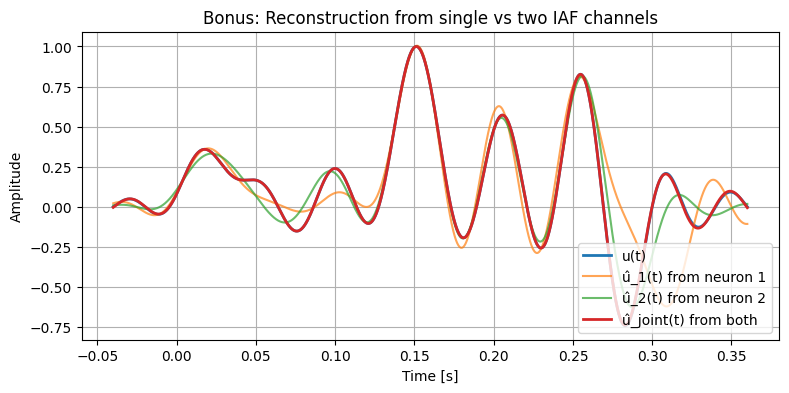

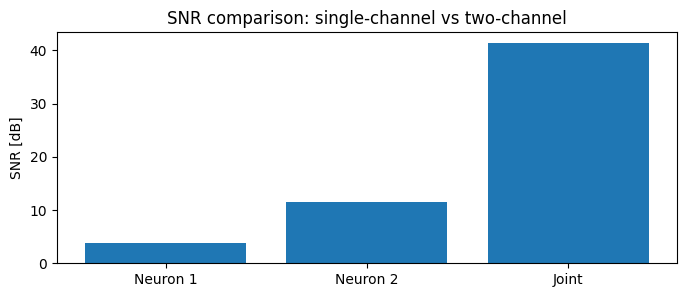

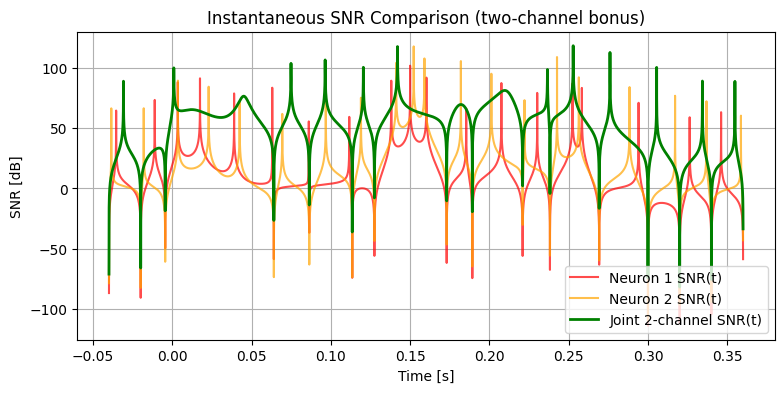

Mean SNRs – Neuron 1: 8.65 dB, Neuron 2: 13.87 dB, Joint: 50.02 dB


In [ ]:
# Bonus: the Two-Channel IAF TEM/TDM


import numpy as np
from scipy.integrate import cumulative_trapezoid as cumtrapz
import matplotlib.pyplot as plt

# this assumes from the main P2:
# should use  t, u, omega already defined
# and we have sinc_basis(t, s, omega) as defined as in the prev. code.

dt = t[1] - t[0]

# here is a simple IAF encoder (the with no sort of feedback)

def iaf_encode(t, u, params):
    b = params["b"]
    kappa = params["kappa"]
    delta = params["delta"]

    V = np.zeros_like(t)
    tk_idx = []

    for i in range(1, len(t)):
        V[i] = V[i - 1] + dt * (b + u[i]) / kappa
        if V[i] >= delta:
            tk_idx.append(i)
            V[i] = 0.0

    return np.array(tk_idx)

# this part of the code corresponds to a single-channel TEM/TDM (in the style of what we saw for HW3)

class IAF_TDM:
    def __init__(self, basis_func, params):
        self.basis_func = basis_func
        self.params = params

    def compute_G(self, t, tk_idx):
        tk = t[tk_idx]
        s = 0.5 * (tk[:-1] + tk[1:]) # should be the midpointswe find
        G = np.zeros((len(s), len(s)))  # <-- define G before using it
        for i in range(len(s)):
            gk = self.basis_func(t, s[i])
            csum = cumtrapz(gk, dx=dt, initial=0)
            G[:, i] = np.diff(csum[tk_idx])
        return s, G

    def compute_q(self, t, tk_idx):
        tk = t[tk_idx]
        kappa = self.params["kappa"]
        delta = self.params["delta"]
        b = self.params["b"]
        q = kappa * delta - b * np.diff(tk)
        return q

    def decode(self, t, tk_idx, rcond=1e-7):
        if len(tk_idx) < 2:
            raise ValueError("Not enough spikes to decode.")
        s, G = self.compute_G(t, tk_idx)
        q = self.compute_q(t, tk_idx)
        c_rec = np.linalg.pinv(G, rcond=rcond) @ q

        u_rec = np.zeros_like(t)
        for ck, sk in zip(c_rec, s):
            u_rec += ck * self.basis_func(t, sk)
        return u_rec

# this is going to be the two-channel TEM/TDM.

class TwoIAF_TDM:
    def __init__(self, basis_func, params1, params2):
        self.basis_func = basis_func
        self.p1 = params1
        self.p2 = params2

    def compute_G_q(self, t, tk1_idx, tk2_idx):
        tk1 = t[tk1_idx]
        tk2 = t[tk2_idx]

        #again we have the midpoints for each of the neuron(s)
        s1 = 0.5 * (tk1[:-1] + tk1[1:]) if len(tk1) > 1 else np.array([])
        s2 = 0.5 * (tk2[:-1] + tk2[1:]) if len(tk2) > 1 else np.array([])
        s = np.concatenate([s1, s2])

        #this is going to build G1, G2
        G1 = np.zeros((len(s1), len(s)))
        G2 = np.zeros((len(s2), len(s)))

        for i in range(len(s)):
            gk = self.basis_func(t, s[i])
            csum = cumtrapz(gk, dx=dt, initial=0)
            if len(s1) > 0:
                G1[:, i] = np.diff(csum[tk1_idx])
            if len(s2) > 0:
                G2[:, i] = np.diff(csum[tk2_idx])

        G = np.vstack([G1, G2])

        # THis is going to build q1, q2 from the different IAF constraints
        k1, d1, b1 = self.p1["kappa"], self.p1["delta"], self.p1["b"]
        k2, d2, b2 = self.p2["kappa"], self.p2["delta"], self.p2["b"]

        q1 = k1 * d1 - b1 * np.diff(tk1) if len(tk1) > 1 else np.array([])
        q2 = k2 * d2 - b2 * np.diff(tk2) if len(tk2) > 1 else np.array([])

        q = np.concatenate([q1, q2])

        return s, G, q

    def decode(self, t, tk1_idx, tk2_idx, rcond=1e-7):
        s, G, q = self.compute_G_q(t, tk1_idx, tk2_idx)

        if len(q) < len(s):
            raise ValueError("Underdetermined: not enough spikes across channels.")

        c_rec = np.linalg.pinv(G, rcond=rcond) @ q

        u_rec = np.zeros_like(t)
        for ck, sk in zip(c_rec, s):
            u_rec += ck * self.basis_func(t, sk)
        return u_rec

#  Here we choose the diff neuron parameters
# Use two different biases so that each alone is weak,
# but together yields a strong, overdetermined system.

iaf1_params = dict(kappa=1.0, delta=0.01, b=0.2)   #should be fewer spikes
iaf2_params = dict(kappa=1.0, delta=0.01, b=0.3)   #and then slightly more spikes

# now we  encode with both of our neurons

tk1_idx = iaf_encode(t, u, iaf1_params)
tk2_idx = iaf_encode(t, u, iaf2_params)

print(f"Neuron 1 spikes: {len(tk1_idx)}")
print(f"Neuron 2 spikes: {len(tk2_idx)}")

# decoding step

basis = lambda tt, s: sinc_basis(tt, s, omega)

tdm1 = IAF_TDM(basis, iaf1_params)
tdm2 = IAF_TDM(basis, iaf2_params)

u1_rec = tdm1.decode(t, tk1_idx)
u2_rec = tdm2.decode(t, tk2_idx)

#  this is the joint 2-channel  <-- also decoding

tdm2ch = TwoIAF_TDM(basis, iaf1_params, iaf2_params)
u_joint = tdm2ch.decode(t, tk1_idx, tk2_idx)

#all of our metrics

def overall_SNR(u_true, u_est):
    num = np.sum(u_true**2)
    den = np.sum((u_true - u_est)**2) + 1e-18
    return 10 * np.log10(num / den)

snr1 = overall_SNR(u, u1_rec)
snr2 = overall_SNR(u, u2_rec)
snr_joint = overall_SNR(u, u_joint)

print("Single-branch SNRs:")
print(f"  Neuron 1 only: {snr1:.2f} dB")
print(f"  Neuron 2 only: {snr2:.2f} dB")
print(f"Two-channel joint SNR: {snr_joint:.2f} dB")

#plots

plt.figure(figsize=(9,4))
plt.plot(t, u, label="u(t)", linewidth=2)
plt.plot(t, u1_rec, label="û_1(t) from neuron 1", alpha=0.7)
plt.plot(t, u2_rec, label="û_2(t) from neuron 2", alpha=0.7)
plt.plot(t, u_joint, label="û_joint(t) from both", linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend(loc="lower right")
plt.grid(True)
plt.title("Bonus: Reconstruction from single vs two IAF channels")
plt.show()

plt.figure(figsize=(8,3))
plt.bar(["Neuron 1","Neuron 2","Joint"], [snr1, snr2, snr_joint])
plt.ylabel("SNR [dB]")
plt.title("SNR comparison: single-channel vs two-channel")
plt.show()


# next plot is going to be the instantaneous SNR Plot.

def SNR_t(u_true, u_est):
    """Instantaneous SNR in dB."""
    eps = 1e-12
    return 10 * np.log10((u_true**2 + eps) / ((u_true - u_est)**2 + eps))

snr1_t = SNR_t(u, u1_rec)
snr2_t = SNR_t(u, u2_rec)
snr_joint_t = SNR_t(u, u_joint)

plt.figure(figsize=(9,4))
plt.plot(t, snr1_t, label="Neuron 1 SNR(t)", color="red", alpha=0.7)
plt.plot(t, snr2_t, label="Neuron 2 SNR(t)", color="orange", alpha=0.7)
plt.plot(t, snr_joint_t, label="Joint 2-channel SNR(t)", color="green", linewidth=2)
plt.title("Instantaneous SNR Comparison (two-channel bonus)")
plt.xlabel("Time [s]")
plt.ylabel("SNR [dB]")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#another summary readout
print(f"Mean SNRs – Neuron 1: {np.mean(snr1_t):.2f} dB, Neuron 2: {np.mean(snr2_t):.2f} dB, Joint: {np.mean(snr_joint_t):.2f} dB")


**Can this circuit under the right condition/IAF setup faithfully recover  u ? Why or why not. (2.5ptpt)**

Yes, I do believe that this 2-channel IAF circuit is able to faithfully recover *u(t)* under the appropriate parameter choices, because together these two neurons are able to generate enough of the independent spike-time constraints to uniquely determine the coefficients of the known bandlimited signal space.

In our setup, both of the neurons are able to observe the same stimulus but with using different IAF parameters, which would then lead to more distinct spike trains (with 13 spikes in neuron 1, and 17 in neuron 2).

Each interspike interval enforces an integral relation using the form:

> ∫u(t) dt = κδ − bΔt

And when combining all of the intervals from both of the neurons, they yield an overdetermined linear system:

> Gc = q

for the sinc coefficients. Additionaly, when this system has a full column rank and is well conditioned, it seems that the time decoding machine is able to invert it accurately.

This joint reconstruction SNR of about **41.3 dB** could also indicate that the two-channel encoding captures essentially all of the information in *u(t)*, despite each of the neurons being insufficient on its own.


**Under what condition can this circuit recover  u  better than each branch on it own? (5pt)**

From everything we have seen so far, this circuit is able to recover *u(t)* better than either branch alone when the two IAF neurons produce complementary (not anything redundant) spike trains so that the combined constraints are able to form an overdetermined and a well-conditioned system for the underlying signal coefficients.

In more concrete terms, I could say that this requires choosing different parameters (perhaps bias and/or threshold, or possibly the capacitance) so that neuron 1 and neuron 2 are able to fire at different times in response to the same *u(t)*, instead of accidently ending up mirroring each other.

In this way, each branch on its own may be under-sampled or ill-conditioned (think a few spikes, or some poorly placed intervals), which is then exactly what we are going to see numerically:

- Neuron 1 alone yields about **3.9 dB**  
- And Neuron 2 yields about **11.5 dB**

And then when we end up stacking their equations, we are effectively increasing the number and the diversity of sampling intervals, so that *G* is built from both the spike trains has a higher rank and then better conditioning overall. Naturally, the least-squares solution is then able to recover *u(t)* with now a much smaller error, as reflected by the jump to about **41.3 dB SNR**.
